# FRE-GY 7871A — Assignment 5: What do voters care about in the 2026 midterms, and does it move markets?

**Task.** (1) Use news and social/forum data plus topic modelling to find the issues US voters care about most ahead of the Nov 3, 2026 midterms. (2) Build a daily sentiment index for those issues and correlate it with the market-implied probability of a **Democratic sweep** (Polymarket: "D Senate, D House"). (3) Build a "midterm basket" of stocks that should win or lose from the result, and relate the sentiment index to the basket's market-adjusted performance. (4) Draw conclusions.

**Window.** Aug 1 – Oct 5, 2026 (about 66 calendar days, 46 trading days).

**Data (all free).** Google News RSS (headlines), The Guardian Open Platform (articles), Hacker News (forum comments), Polymarket (contract prices), Yahoo Finance (stock prices).

**Methods from class.** Excess returns over the market and Granger tests in both directions (Souza et al.); lexicon sentiment (Carvalho & Plastino); Hu-Liu negative-word share (Sacerdote et al.). New here: topic modelling (NMF) and prediction-market prices.

**Honest framing.** News attention is a proxy for what voters care about, not a poll. About 10 weeks of daily data gives low power, so a null result is a legitimate finding.

## 0. Setup

In [15]:
import os, re, warnings
from datetime import date
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
warnings.filterwarnings("ignore")

START, END = date(2026, 8, 1), date(2026, 10, 5)
BENCH = "SPY"
LAGS = [1, 2]            # short lags: only ~46 trading days / ~65 calendar days
N_PERM = 2000
FORCE_REFETCH = False    # True = ignore cached prices and re-download

# Midterm basket: ticker -> (expected sign of the effect of a Democratic sweep, group). These are hypotheses
# from each company's exposure to policy (IRA credits, ACA/Medicaid, tariffs, oil regulation, detention, crypto, enforcement
# contracts); section 8 checks the signs against the market.
MIDTERM_BASKET = {
    "FSLR": (+1, "clean energy"), "ENPH": (+1, "clean energy"), "NEE": (+1, "clean energy"),
    "CNC": (+1, "ACA/Medicaid insurers"), "MOH": (+1, "ACA/Medicaid insurers"),
    "HCA": (+1, "hospitals"),
    "TGT": (+1, "tariff-exposed importers"), "NKE": (+1, "tariff-exposed importers"),
    "XOM": (-1, "oil & gas"), "CVX": (-1, "oil & gas"),
    "GEO": (-1, "private prisons/detention"), "CXW": (-1, "private prisons/detention"),
    "COIN": (-1, "crypto"), "PLTR": (-1, "federal enforcement tech"),
}
os.makedirs("outputs", exist_ok=True); os.makedirs("cache", exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
CAL = pd.date_range(START, END, freq="D")

## 1. Data
`cache/news_all.csv` comes from `collect_news.py`. Google News gives only headlines (about 15 words), the Guardian gives headline + summary + the first part of the article, and Hacker News gives comments that mention the midterms. The outlet suffix on Google News headlines ("... - Fox News") is removed. Duplicate texts are dropped. Posts are dated by US-Eastern calendar date.

In [16]:
def to_utc(s):
    """Parse timestamps one at a time (mixed formats silently become NaT with vectorised parsing)."""
    return s.map(lambda x: pd.to_datetime(x, utc=True, errors="coerce"))

def strip_outlet(t):
    m = re.match(r"^(.*)\s[-–|]\s([^-–|]{2,45})$", t)
    return m.group(1) if m else t

news = pd.read_csv("cache/news_all.csv", dtype={"id": str})
news["created_at"] = to_utc(news["created_at"])
news = news.dropna(subset=["created_at"])
news["et"] = news["created_at"].dt.tz_convert("America/New_York")
news["date"] = news["et"].dt.date
news = news[(news["date"] >= START) & (news["date"] <= END)].copy()
news["body"] = np.where(news.platform == "gnews", news.text.map(strip_outlet), news.text)
news = news[(news.platform != "hn") | news.text.str.contains("midterm", case=False)]      # keep only forum posts that mention the midterms
news = news.drop_duplicates(["platform", "body"]).reset_index(drop=True)
news["lede"] = news["body"].str[:300]                         # headline + opening: the same-length text for every source
news["long"] = news["n_words"] > 150
print(f"{len(news):,} documents, {news.date.nunique()} days")
per_day = news.groupby(["platform", "date"]).size().groupby("platform").describe()[["min", "50%", "max"]]
display(news.groupby("platform").agg(docs=("id", "size"), mean_words=("n_words", "mean")).round(1).join(per_day.rename(columns={"50%": "median/day"})))

7,003 documents, 66 days


,docs,mean_words,min,median/day,max
platform,,,,,
gnews,6316,14.6,8.0,94.5,179.0
guardian,437,356.4,1.0,6.0,17.0
hn,250,100.7,1.0,3.0,19.0


## 2. Topic discovery (NMF)
We fit a TF-IDF + **NMF** topic model (deterministic: `init="nndsvd"`) on all documents with 15 topics. Generic election words are removed so that topics are not just "midterms". Each document is assigned its strongest topic. We print the top terms, the number of documents, and an example headline; the labels in the next cell were assigned by reading these top terms and examples (the "LLM-in-the-loop" step), and the cell checks that each label still matches its top terms if you change settings.

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import NMF

GEN = {"midterm","midterms","election","elections","2026","says","say","said","new","just","like","year","years","day","week","news",
       "live","update","updates","latest","video","watch","explained","analysis","opinion","us","u.s","donald","president","republican",
       "republicans","democrats","democratic","party","gop","house","senate","americans","american","state","states","vote","voters",
       "voting","voter","here's","get","make","know","need","going","will","may","could","would","one","two","also","trump","trump's",
       "ahead","november"}
tf = TfidfVectorizer(stop_words=list(set(ENGLISH_STOP_WORDS) | GEN), min_df=5, max_df=0.15, ngram_range=(1, 2),
                     token_pattern=r"[A-Za-z][A-Za-z']{2,}", sublinear_tf=True)
X = tf.fit_transform(news["body"]); terms = np.array(tf.get_feature_names_out())
K = 15
nmf = NMF(n_components=K, init="nndsvd", random_state=0, max_iter=1000).fit(X)
W = nmf.transform(X); news["topic"] = np.where(W.max(1) > 0, W.argmax(1), -1)
rows = []
for i, comp in enumerate(nmf.components_):
    idx = np.where(news.topic == i)[0]
    ex = news["body"].iloc[idx[np.argsort(-W[idx, i])[:1]]].str[:80].tolist()
    rows.append({"topic": i, "docs": len(idx), "share %": round(100 * len(idx) / len(news), 1),
                 "top terms": ", ".join(terms[comp.argsort()[::-1][:8]]), "example": ex[0] if ex else ""})
topics = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", 90); pd.set_option("display.width", 250)
display(topics)

,topic,docs,share %,top terms,example
0,0,295,4.2,"court, supreme, supreme court, restrictions, missouri, court blocks, mail, court rejects",State Supreme Court Elections to Watch This November
1,1,382,5.5,"poll, poll shows, shows, finds, poll finds, lead, race, texas","New poll could have grimmest midterm news yet for Trump, Republicans"
2,2,325,4.6,"iran, war, iran war, end, war end, prices, gas, gas prices",Lara Trump says Iran war 'could cost' Donald Trump the midterms
3,3,303,4.3,"primary, results, primaries, primary results, florida, wisconsin, minnesota, tennessee",Primary Day for 6 states ahead of November midterm elections
4,4,352,5.0,"mail, ballots, mail ballots, order, judge, postal, postal service, usps",What to know about mail-in voting for the 2026 midterms
5,5,139,2.0,"approval, rating, approval rating, low, record low, record, hits, falls",Donald Trump’s approval rating
6,6,267,3.8,"races, key, key races, control, decide, texas, races decide, georgia",The Top Governors' Races to Watch This November
7,7,204,2.9,"polls, lead, texas, district polls, ice, lead polls, blue, predictions",Why do the polls keep misfiring?
8,8,169,2.4,"data, data centers, centers, center, data center, backlash, issue, center backlash",AI Data Centers Become a Midterm Flashpoint for Voters
9,9,129,1.8,"guide, register, nov, colorado, county, guide colorado, guide nov, mississippi",US midterm elections 2026: The FT’s guide


In [18]:
# Labels assigned after reading the table above: topic id -> (label, kind, a word that must appear in the topic's top terms).
# kind: 'issue' = a problem/policy voters could care about; 'referendum' = about the president; 'process' = how the election is run or covered;
# 'general' = catch-all campaign coverage. The word check warns you if you changed settings and the ids no longer match.
TOPIC_LABELS = {
    0:  ("Supreme Court rulings on mail ballots", "process", "court"),
    1:  ("Polls and horse race", "process", "poll"),
    2:  ("Iran war, gas prices and cost of living", "issue", "iran"),
    3:  ("Primaries and results", "process", "primary"),
    4:  ("Mail-in voting and the Postal Service", "process", "mail"),
    5:  ("Trump approval rating", "referendum", "approval"),
    6:  ("Key races to watch", "process", "races"),
    7:  ("Why polls misfire / predictions", "process", "polls"),
    8:  ("Data centers and AI backlash", "issue", "data"),
    9:  ("Voter guides and registration", "process", "guide"),
    10: ("GOP convention, Vance and Trump rallies", "process", "convention"),
    11: ("Ballot restrictions / what is on the ballot", "process", "ballot"),
    12: ("General campaign and control of Congress", "general", "congress"),
    13: ("GOP promises: dividend / $5,000 checks", "issue", "checks"),
    14: ("Congressional districts, maps and local candidates", "process", "district"),
}
ok = True
for i, (lab, kind, key) in TOPIC_LABELS.items():
    if key not in topics.loc[i, "top terms"]:
        ok = False; print(f"WARNING: topic {i} no longer looks like '{lab}' (expected '{key}' in its top terms); re-label.")
topics["label"] = topics["topic"].map(lambda i: TOPIC_LABELS[i][0]); topics["kind"] = topics["topic"].map(lambda i: TOPIC_LABELS[i][1])
display(topics.groupby("kind")[["docs", "share %"]].sum())
display(topics[topics.kind.isin(["issue", "referendum"])][["label", "docs", "share %", "top terms"]])
print("labels match the topics" if ok else "check the warnings above")
topics.drop(columns="example").to_csv("outputs/table0_topics.csv", index=False)

,docs,share %
kind,,
general,3324,47.5
issue,704,10.0
process,2799,39.9
referendum,139,2.0


,label,docs,share %,top terms
2,"Iran war, gas prices and cost of living",325,4.6,"iran, war, iran war, end, war end, prices, gas, gas prices"
5,Trump approval rating,139,2.0,"approval, rating, approval rating, low, record low, record, hits, falls"
8,Data centers and AI backlash,169,2.4,"data, data centers, centers, center, data center, backlash, issue, center backlash"
13,"GOP promises: dividend / $5,000 checks",210,3.0,"win, promises, plan, offers, congress, dividend, checks, checks win"


labels match the topics


## 3. Issue lexicon and prominence
NMF mostly separates *campaign process* (mail-ballot rulings, primaries, polls, local candidates) from a few *issue* clusters (Iran war and gas prices, data centers, Trump's approval). Short headlines rarely name an issue, so we complement NMF with an **issue lexicon** built from the NMF top terms and standard policy categories. A document is tagged with an issue if the issue appears in its first 300 characters (headline + opening), or, for long articles, at least 3 times in the full text. Tags are not mutually exclusive.

**Prominence** is measured two ways: the share of all documents that carry the issue, and the share among documents that are about *voters, polls or surveys*, which is closer to "what voters care about" (voter-framed share). Issues are ranked by the voter-framed share. This is attention in the news, not a poll of voters.

In [19]:
ISSUES = {
    "economy_prices":   (r"\beconom|inflation|\bprices?\b|cost of living|afford|grocer|\bjobs?\b|unemploy|\bwages?\b|recession|gas prices|housing|mortgage|interest rates?|paycheck|\bgas\b", "Economy & prices"),
    "iran_war_foreign": (r"\biran|\bwar\b|israel|ukraine|russia|china|gaza|hormuz|military|troops|foreign policy|venezuela|netanyahu", "Iran war & foreign policy"),
    "immigration":      (r"immigra|(?-i:\bICE\b)|deport|\bborder\b|migrant|asylum", "Immigration & ICE"),
    "democracy_voting": (r"mail[- ]in|mail ballot|voting rights|gerrymander|redistrict|voter id|election integrity|democracy|voting map|election interference|disenfranchis|polling places?|rigged|cancel the midterms", "Democracy & voting rules"),
    "ai_tech":          (r"(?-i:\bAI\b)|artificial intelligence|data cent|chatgpt|big tech|crypto|bitcoin|tech compan", "AI, data centers & tech"),
    "energy_climate":   (r"\benergy|climate|\boil\b|electric(ity)? bills?|power bills?|utilit|solar|renewable|diesel", "Energy & climate"),
    "taxes_budget":     (r"\btaxe?s?\b|budget|deficit|shutdown|government spending|social security|national debt", "Taxes, budget & shutdown"),
    "health_care":      (r"health ?care|medicaid|medicare|obamacare|affordable care act|health insurance|hospital|drug prices|\baca\b", "Health care"),
    "tariffs_trade":    (r"tariff|trade war|trade deal|trade dispute", "Tariffs & trade"),
    "crime_guns":       (r"\bcrime|police|shooting|\bguns?\b|national guard", "Crime & guns"),
    "abortion":         (r"abortion|roe v|reproductive|contracepti|\bivf\b", "Abortion"),
}
LABEL = {k: v[1] for k, v in ISSUES.items()}
for k, (pat, _) in ISSUES.items():
    head = news["lede"].str.contains(pat, regex=True, flags=re.I)
    body = news["body"].str.count(re.compile(pat, re.I)) >= 3
    news["i_" + k] = head | (news["long"] & body)
VOTER_FRAMED = news["lede"].str.contains(r"voters?\b|polls?\b|poll shows|survey|americans (say|think|worry)|poll finds", regex=True, flags=re.I)
rows = []
for k in ISSUES:
    m = news["i_" + k]
    rows.append({"issue": LABEL[k], "docs": int(m.sum()), "share of all docs %": round(100 * m.mean(), 1),
                 "voter-framed share %": round(100 * m[VOTER_FRAMED].mean(), 1),
                 "gnews %": round(100 * m[news.platform == "gnews"].mean(), 1),
                 "guardian %": round(100 * m[news.platform == "guardian"].mean(), 1),
                 "hn %": round(100 * m[news.platform == "hn"].mean(), 1), "key": k})
prom = pd.DataFrame(rows).sort_values("voter-framed share %", ascending=False).reset_index(drop=True)
display(prom.drop(columns="key")); prom.drop(columns="key").to_csv("outputs/table1_issue_prominence.csv", index=False)
print(f"voter-framed documents: {int(VOTER_FRAMED.sum()):,} of {len(news):,}")
KEY_ISSUES = prom["key"].head(5).tolist()
print("KEY ISSUES (top 5 by voter-framed share):", [LABEL[k] for k in KEY_ISSUES])

# hand-check sample for the lexicon (optional): 8 tagged documents per issue
samp = pd.concat([news[news["i_" + k]].sample(min(8, int(news["i_" + k].sum())), random_state=1).assign(issue=LABEL[k]) for k in ISSUES])
samp[["issue", "platform", "lede"]].assign(correct="").to_csv("outputs/tag_validation_sample.csv", index=False)

,issue,docs,share of all docs %,voter-framed share %,gnews %,guardian %,hn %
0,Economy & prices,433,6.2,7.4,4.7,21.1,16.8
1,Democracy & voting rules,527,7.5,3.9,7.6,8.5,3.2
2,Iran war & foreign policy,529,7.6,3.8,5.0,37.5,20.0
3,"AI, data centers & tech",234,3.3,3.0,2.8,7.8,8.8
4,Immigration & ICE,99,1.4,2.3,1.2,4.3,1.6
5,"Taxes, budget & shutdown",80,1.1,0.6,0.9,3.4,3.6
6,Health care,55,0.8,0.6,0.7,1.6,2.4
7,Tariffs & trade,65,0.9,0.5,0.7,3.4,2.0
8,Energy & climate,110,1.6,0.3,0.6,11.4,8.8
9,Abortion,15,0.2,0.2,0.2,0.9,0.0


voter-framed documents: 1,673 of 7,003
KEY ISSUES (top 5 by voter-framed share): ['Economy & prices', 'Democracy & voting rules', 'Iran war & foreign policy', 'AI, data centers & tech', 'Immigration & ICE']


## 4. Sentiment scoring
Two lexicon scorers on the first 300 characters (so a 15-word headline and a 2,000-word article are scored on comparable text):
- **VADER compound** (-1…+1), the main measure.
- **Hu-Liu negative-word share**, standardised (robustness; as in Sacerdote et al.). Words like "war" or "crisis" count as negative, which is part of the tone of coverage about those issues.

The score measures the **tone of coverage** about an issue, not the opinion of voters.

In [20]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()
try:
    import nltk; nltk.download("opinion_lexicon", quiet=True)
    from nltk.corpus import opinion_lexicon
    NEG = set(opinion_lexicon.negative()); LEXNAME = "Hu-Liu (NLTK opinion_lexicon)"
except Exception:
    NEG = {w for w, v in sia.lexicon.items() if v <= -1.5 and w.isalpha()}; LEXNAME = "VADER-lexicon fallback"
print("negative lexicon:", LEXNAME, len(NEG), "words")
URLS = re.compile(r"https?://\S+|@\w+"); TOK = re.compile(r"[a-z']+")
news["vader"] = news["lede"].map(lambda s: sia.polarity_scores(URLS.sub(" ", s))["compound"])
def neg_share(s):
    w = TOK.findall(s.lower()); return sum(x in NEG for x in w) / len(w) if w else np.nan
news["neg_share"] = news["lede"].map(neg_share)
news["neg_z"] = (news["neg_share"] - news["neg_share"].mean()) / news["neg_share"].std()
display(news.groupby("platform")[["vader", "neg_share"]].mean().round(3))

negative lexicon: Hu-Liu (NLTK opinion_lexicon) 4783 words


,vader,neg_share
platform,,
gnews,0.011,0.033
guardian,-0.093,0.041
hn,-0.042,0.036


## 5. Daily sentiment indices
Calendar-day means (US-Eastern dates). A day needs at least 5 documents, otherwise it is missing. Series:
- **All midterm coverage**: every document.
- One series per **key issue** (the top-5 issues from section 3).
- **Key-issue composite**: documents tagged with any key issue. This is the main index.
- **Party tone gap**: mean tone of headlines that mention Democrats (and not Republicans) minus those that mention Republicans (and not Democrats). A direct "who is the news framing well" measure.

,count,mean,std,min,max
Key-issue composite (main),65.0,-0.100,0.129,-0.405,0.187
All midterm coverage,66.0,0.001,0.069,-0.148,0.175
Economy & prices,44.0,-0.129,0.175,-0.452,0.238
Democracy & voting rules,32.0,0.024,0.168,-0.335,0.302
Iran war & foreign policy,45.0,-0.298,0.166,-0.681,0.041
"AI, data centers & tech",20.0,-0.030,0.138,-0.309,0.256
Immigration & ICE,1.0,-0.212,NaN,-0.212,-0.212
Party tone gap (Dem - Rep),57.0,0.180,0.171,-0.315,0.542
"Key-issue composite, Hu-Liu (sign flipped)",65.0,-0.114,0.272,-0.916,0.376


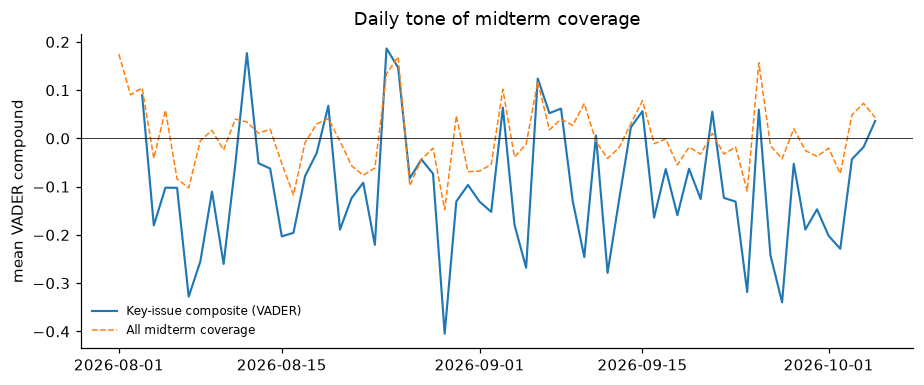

Trend in the key-issue composite: -0.0003 per day (p = 0.748, n = 65); mean -0.100


In [21]:
def daily_mean(d, col="vader", min_n=5):
    g = d.groupby("date")[col].agg(["mean", "size"]); s = g["mean"].where(g["size"] >= min_n)
    s.index = pd.to_datetime(s.index); return s.reindex(CAL)

any_key = news[["i_" + k for k in KEY_ISSUES]].any(axis=1)
sent = {"Key-issue composite (main)": daily_mean(news[any_key]), "All midterm coverage": daily_mean(news)}
for k in KEY_ISSUES: sent[LABEL[k]] = daily_mean(news[news["i_" + k]])
dem = news.lede.str.contains(r"democrat|\bdems\b", case=False, regex=True); rep = news.lede.str.contains(r"republican|\bgop\b", case=False, regex=True)
sent["Party tone gap (Dem - Rep)"] = daily_mean(news[dem & ~rep]) - daily_mean(news[rep & ~dem])
sent["Key-issue composite, Hu-Liu (sign flipped)"] = -daily_mean(news[any_key], col="neg_z")
S = pd.DataFrame(sent)
cnt = pd.DataFrame({"docs/day (composite)": news[any_key].groupby(pd.to_datetime(news[any_key]["date"])).size().reindex(CAL)})
display(S.describe().T[["count", "mean", "std", "min", "max"]].round(3))
fig, ax = plt.subplots(figsize=(8.5, 3.6))
ax.plot(S.index, S["Key-issue composite (main)"], lw=1.4, label="Key-issue composite (VADER)")
ax.plot(S.index, S["All midterm coverage"], lw=1, ls="--", label="All midterm coverage")
ax.axhline(0, color="k", lw=.5); ax.set_ylabel("mean VADER compound"); ax.legend(frameon=False, fontsize=8)
ax.set_title("Daily tone of midterm coverage"); fig.tight_layout(); fig.savefig("outputs/fig_sentiment.png"); plt.show()
S.to_csv("outputs/table2_sentiment_daily.csv")
# trend of the main index
y = S["Key-issue composite (main)"].dropna(); t = (y.index - y.index[0]).days.values
w = sm.OLS(y.values, sm.add_constant(t)).fit(cov_type="HAC", cov_kwds={"maxlags": 3})
print(f"Trend in the key-issue composite: {w.params[1]:+.4f} per day (p = {w.pvalues[1]:.3f}, n = {len(y)}); mean {y.mean():+.3f}")

## 6. The market: probability of a Democratic sweep
`collect_markets.py` downloads the daily price history of the Polymarket contract **"2026 Balance of Power: D Senate, D House"** (price = implied probability that Democrats win both chambers). Each price point is dated by its US-Eastern timestamp, which is roughly the end of that day. The same file has the House-control contract and the other balance-of-power outcomes for robustness.

markets available: ['BoP_Other', 'D_House', 'D_Senate', 'D_Senate_D_House', 'D_Senate_R_House', 'R_House', 'R_Senate', 'R_Senate_D_House', 'R_Senate_R_House']
P(Democratic sweep): start 0.445 -> end 0.655; min 0.445, max 0.665; mean |daily change| 0.0083; missing days 0


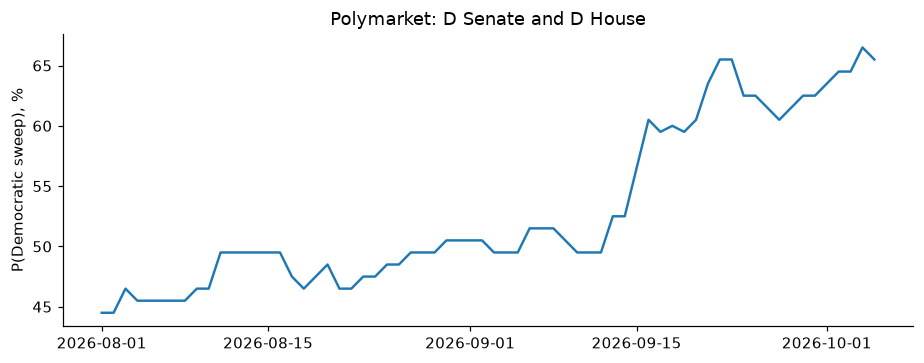

In [22]:
pm = pd.read_csv("cache/polymarket_prices.csv")
pm["ts"] = to_utc(pm["ts_utc"]); pm["date"] = pm["ts"].dt.tz_convert("America/New_York").dt.date
wide = pm.pivot_table(index="date", columns="market", values="price", aggfunc="last"); wide.index = pd.to_datetime(wide.index)
wide = wide.reindex(pd.date_range(START - pd.Timedelta(days=7), END, freq="D")).ffill(limit=3)
P = wide["D_Senate_D_House"]
if "D_Senate" not in wide.columns and {"D_Senate_D_House", "D_Senate_R_House"} <= set(wide.columns):
    wide["D_Senate"] = wide["D_Senate_D_House"] + wide["D_Senate_R_House"]
print("markets available:", sorted(wide.columns))
Pw = P.reindex(CAL)
print(f"P(Democratic sweep): start {Pw.dropna().iloc[0]:.3f} -> end {Pw.dropna().iloc[-1]:.3f}; min {Pw.min():.3f}, max {Pw.max():.3f}; "
      f"mean |daily change| {Pw.diff().abs().mean():.4f}; missing days {int(Pw.isna().sum())}")
fig, ax = plt.subplots(figsize=(8.5, 3.4))
ax.plot(Pw.index, 100 * Pw, lw=1.6); ax.set_ylabel("P(Democratic sweep), %"); ax.set_title("Polymarket: D Senate and D House")
fig.tight_layout(); fig.savefig("outputs/fig_market.png"); plt.show()

## 7. Sentiment vs the probability of a Democratic sweep
**Design.** For each sentiment series: (a) correlation of **levels** (shown, but two trending series can correlate spuriously), (b) correlation of **daily changes**, which is the cleaner test, (c) lead-lag correlations of ΔSentiment with ΔProbability, and (d) **Granger tests in both directions** at lags 1 and 2 (z-scored, first-differenced, manual F-test cross-checked against statsmodels, permutation p-value at lag 1). A significant result would mean predictive precedence, not causation.

In [23]:
from statsmodels.tsa.stattools import grangercausalitytests
def zs(s): return (s - s.mean()) / s.std()
def lagmat(s, L): return np.column_stack([s.shift(i).values for i in range(1, L + 1)])
def granger_F(df, cause, effect, L):
    d = df[[effect, cause]].dropna().reset_index(drop=True); y = d[effect]; Y = y.values[L:]
    Xr = np.column_stack([np.ones(len(Y)), lagmat(y, L)[L:]]); Xu = np.column_stack([Xr, lagmat(d[cause], L)[L:]])
    rss = lambda X: ((Y - X @ np.linalg.lstsq(X, Y, rcond=None)[0]) ** 2).sum()
    rr, ru = rss(Xr), rss(Xu); df2 = len(Y) - Xu.shape[1]
    if df2 <= 0: return np.nan, np.nan
    F = ((rr - ru) / L) / (ru / df2); return F, stats.f.sf(F, L, df2)
def sm_granger(df, cause, effect, L):
    d = df[[effect, cause]].dropna()
    try: res = grangercausalitytests(d, maxlag=L, verbose=False)
    except TypeError: res = grangercausalitytests(d, maxlag=L)          # newer statsmodels has no verbose argument
    return res[L][0]["ssr_ftest"][:2]
def perm_p(df, cause, effect, L, B=N_PERM, seed=0):
    d = df[[effect, cause]].dropna().copy(); obs = granger_F(d, cause, effect, L)[0]; rng = np.random.default_rng(seed); hits = 0
    for _ in range(B):
        d[cause] = rng.permutation(d[cause].values); hits += granger_F(d, cause, effect, L)[0] >= obs
    return (hits + 1) / (B + 1)
def lag1_coef(df, cause, effect):
    d = df[[effect, cause]].dropna().reset_index(drop=True)
    X = sm.add_constant(pd.DataFrame({"y1": d[effect].shift(1), "x1": d[cause].shift(1)})).iloc[1:]
    m = sm.OLS(d[effect].iloc[1:], X).fit(); return m.params["x1"], m.tvalues["x1"]
def granger_table(df, pairs, lags):
    out = []
    for label, cause, effect in pairs:
        for L in lags:
            F, p = granger_F(df, cause, effect, L)
            row = {"direction": label, "lag": L, "F": F, "p (F-test)": p, "p (permutation)": perm_p(df, cause, effect, L) if L == 1 else np.nan}
            if L == 1: b, tv = lag1_coef(df, cause, effect); row["lag-1 coef"] = b
            out.append(row)
    return pd.DataFrame(out)

dP = Pw.diff()
rows, lead, panels = [], {}, {}
for name, s in S.items():
    if s.notna().sum() < 15:
        print(f"skipped '{name}': only {int(s.notna().sum())} days with at least 5 documents"); continue
    dS = zs(s).diff(); d = pd.concat([dS.rename("dS"), zs(dP).rename("dP"), zs(s).rename("S"), zs(Pw).rename("P")], axis=1).dropna(subset=["dS", "dP"])
    panels[name] = d
    lv = pd.concat([zs(s).rename("S"), zs(Pw).rename("P")], axis=1).dropna()
    rl = stats.pearsonr(lv["S"], lv["P"]) if len(lv) > 5 else (np.nan, np.nan)
    rc, pc = stats.pearsonr(d["dS"], d["dP"]); sp, psp = stats.spearmanr(d["dS"], d["dP"])
    rows.append({"series": name, "n": len(d), "corr levels": rl[0], "p (levels)": rl[1], "corr changes": rc, "p (changes)": pc,
                 "Spearman changes": sp, "p (Spearman)": psp})
    lead[name] = {L: zs(s).diff().corr(zs(dP).shift(-L)) for L in range(-3, 4)}   # corr(dS_t, dP_{t+L}); L>0: sentiment leads the market
corr_tab = pd.DataFrame(rows); display(corr_tab.round(3)); corr_tab.to_csv("outputs/table3_sentiment_vs_market_corr.csv", index=False)
print("Lead-lag: corr(dSentiment_t, dProbability_t+L); L > 0 means sentiment moves first"); display(pd.DataFrame(lead).T.round(3))
chk = panels["Key-issue composite (main)"][["dP", "dS"]].dropna()
a, b = granger_F(chk, "dS", "dP", 1), sm_granger(chk, "dS", "dP", 1)
print(f"cross-check lag 1  manual F={a[0]:.4f} p={a[1]:.4f}  |  statsmodels F={b[0]:.4f} p={b[1]:.4f}"); assert abs(a[0] - b[0]) < 1e-6
pairs = [("dSentiment -> dP(sweep)", "dS", "dP"), ("dP(sweep) -> dSentiment", "dP", "dS")]
gt = pd.concat([granger_table(p_, pairs, LAGS).assign(series=n) for n, p_ in panels.items()], ignore_index=True)
display(gt[["series", "direction", "lag", "F", "p (F-test)", "p (permutation)", "lag-1 coef"]].round(3)); gt.to_csv("outputs/table4_granger_market.csv", index=False)

skipped 'Immigration & ICE': only 1 days with at least 5 documents


,series,n,corr levels,p (levels),corr changes,p (changes),Spearman changes,p (Spearman)
0,Key-issue composite (main),63,-0.030,0.811,0.152,0.236,0.126,0.324
1,All midterm coverage,65,-0.050,0.693,0.137,0.278,0.191,0.128
2,Economy & prices,36,0.171,0.268,0.109,0.528,0.037,0.831
3,Democracy & voting rules,19,-0.013,0.945,0.003,0.991,-0.115,0.640
4,Iran war & foreign policy,36,0.187,0.219,0.038,0.827,0.006,0.973
5,"AI, data centers & tech",8,-0.197,0.404,-0.372,0.364,-0.229,0.586
6,Party tone gap (Dem - Rep),52,-0.271,0.042,0.080,0.572,0.036,0.798
7,"Key-issue composite, Hu-Liu (sign flipped)",63,0.112,0.372,0.099,0.439,0.008,0.950


Lead-lag: corr(dSentiment_t, dProbability_t+L); L > 0 means sentiment moves first


,-3,-2,-1,0,1,2,3
Key-issue composite (main),-0.044,0.011,-0.121,0.152,0.072,0.101,-0.020
All midterm coverage,-0.086,0.102,-0.245,0.137,0.054,-0.031,0.140
Economy & prices,0.101,0.058,-0.325,0.109,-0.048,0.130,0.003
Democracy & voting rules,-0.206,0.081,0.219,0.003,0.100,-0.208,-0.245
Iran war & foreign policy,-0.090,0.071,-0.036,0.038,0.064,0.309,-0.198
"AI, data centers & tech",-0.175,0.460,-0.168,-0.372,0.441,-0.407,0.037
Party tone gap (Dem - Rep),-0.047,-0.053,0.033,0.080,0.044,0.178,-0.120
"Key-issue composite, Hu-Liu (sign flipped)",-0.190,0.151,0.015,0.099,0.004,-0.011,-0.061


cross-check lag 1  manual F=0.1564 p=0.6939  |  statsmodels F=0.1564 p=0.6939


,series,direction,lag,F,p (F-test),p (permutation),lag-1 coef
0,Key-issue composite (main),dSentiment -> dP(sweep),1,0.156,0.694,0.706,0.037
1,Key-issue composite (main),dSentiment -> dP(sweep),2,0.513,0.601,NaN,NaN
2,Key-issue composite (main),dP(sweep) -> dSentiment,1,0.060,0.808,0.801,-0.040
3,Key-issue composite (main),dP(sweep) -> dSentiment,2,0.015,0.985,NaN,NaN
4,All midterm coverage,dSentiment -> dP(sweep),1,0.101,0.752,0.749,0.031
5,All midterm coverage,dSentiment -> dP(sweep),2,0.120,0.888,NaN,NaN
6,All midterm coverage,dP(sweep) -> dSentiment,1,2.819,0.098,0.112,-0.254
7,All midterm coverage,dP(sweep) -> dSentiment,2,1.053,0.355,NaN,NaN
8,Economy & prices,dSentiment -> dP(sweep),1,0.005,0.947,0.941,0.009
9,Economy & prices,dSentiment -> dP(sweep),2,0.140,0.870,NaN,NaN


## 8. The midterm basket
Stocks chosen for their exposure to the outcome (see the dictionary in section 0). The expected sign is a **hypothesis**; we check it against the market by regressing each stock's daily excess return (over SPY) on the daily change in the sweep probability. Then we form two equal-weight sub-baskets, **Dem-sweep winners** and **Dem-sweep losers**, and their spread (winners minus losers).

45 trading days; winners: ['FSLR', 'ENPH', 'NEE', 'CNC', 'MOH', 'HCA', 'TGT', 'NKE'] | losers: ['XOM', 'CVX', 'GEO', 'CXW', 'COIN', 'PLTR']


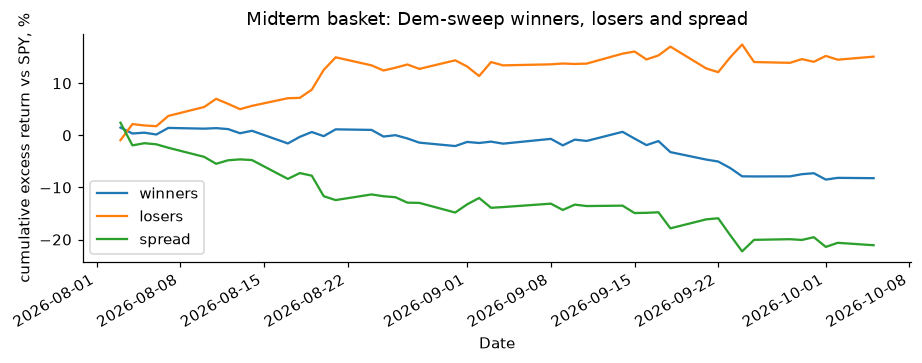

,asset,group,expected sign,beta (excess return % per +1pp P(sweep)),t,p,sign matches,n
0,FSLR,clean energy,+,0.342,0.732,0.464,True,45
1,ENPH,clean energy,+,0.399,1.451,0.147,True,45
2,NEE,clean energy,+,0.046,0.382,0.702,True,45
3,CNC,ACA/Medicaid insurers,+,-0.233,-1.155,0.248,False,45
4,MOH,ACA/Medicaid insurers,+,-0.370,-1.696,0.090,False,45
5,HCA,hospitals,+,-0.068,-0.305,0.760,False,45
6,TGT,tariff-exposed importers,+,-0.064,-0.411,0.681,False,45
7,NKE,tariff-exposed importers,+,-0.046,-0.350,0.726,False,45
8,XOM,oil & gas,-,-0.221,-1.064,0.287,True,45
9,CVX,oil & gas,-,-0.171,-0.864,0.387,True,45


signs matching expectations: 9 of 14 stocks


In [24]:
def load_daily():
    f = "cache/prices_daily_midterm.csv"
    if os.path.exists(f) and not FORCE_REFETCH: return pd.read_csv(f, index_col=0, parse_dates=True)
    import yfinance as yf
    px = yf.download(list(MIDTERM_BASKET) + [BENCH], start="2026-07-20", end="2026-10-07", auto_adjust=True, progress=False)["Close"]
    px.index = pd.to_datetime(px.index).tz_localize(None).normalize(); px.to_csv(f); return px
px = load_daily(); px = px[px.index.dayofweek < 5].dropna(subset=[BENCH])
missing = [t for t in MIDTERM_BASKET if t not in px.columns or px[t].isna().mean() > .3]
if missing: print("WARNING: dropped tickers with missing data:", missing)
TICK = [t for t in MIDTERM_BASKET if t not in missing]
ret = px[TICK + [BENCH]].pct_change(fill_method=None)
ret = ret[(ret.index >= pd.Timestamp(START)) & (ret.index <= pd.Timestamp(END))]
exc = ret[TICK].sub(ret[BENCH], axis=0); TDAYS = exc.index
win = [t for t in TICK if MIDTERM_BASKET[t][0] > 0]; los = [t for t in TICK if MIDTERM_BASKET[t][0] < 0]
bk = pd.DataFrame({"winners": exc[win].mean(axis=1), "losers": exc[los].mean(axis=1)}); bk["spread"] = bk["winners"] - bk["losers"]
print(len(TDAYS), "trading days;", "winners:", win, "| losers:", los)
cum = (1 + bk).cumprod() - 1
fig, ax = plt.subplots(figsize=(8.5, 3.4)); (100 * cum).plot(ax=ax); ax.set_ylabel("cumulative excess return vs SPY, %")
ax.set_title("Midterm basket: Dem-sweep winners, losers and spread"); fig.tight_layout(); fig.savefig("outputs/fig_basket.png"); plt.show()

# market-implied check of the expected signs: daily excess return on the daily change in P(sweep) (close-to-close, trading days)
Pfull = P.reindex(pd.date_range(TDAYS.min() - pd.Timedelta(days=7), END)).ffill()
Pt = Pfull.reindex(TDAYS.insert(0, TDAYS.min() - pd.offsets.BDay(1)))
dPt = Pt.diff().reindex(TDAYS)
rows = []
for t in TICK + ["winners", "losers", "spread"]:
    y = exc[t] if t in TICK else bk[t]; d = pd.concat([y.rename("y"), (100 * dPt).rename("x")], axis=1).dropna()
    m = sm.OLS(100 * d["y"], sm.add_constant(d["x"])).fit(cov_type="HAC", cov_kwds={"maxlags": 1})
    exp = MIDTERM_BASKET[t][0] if t in TICK else {"winners": 1, "losers": -1, "spread": 1}[t]
    rows.append({"asset": t, "group": MIDTERM_BASKET[t][1] if t in TICK else "sub-basket", "expected sign": "+" if exp > 0 else "-",
                 "beta (excess return % per +1pp P(sweep))": m.params["x"], "t": m.tvalues["x"], "p": m.pvalues["x"], "sign matches": np.sign(m.params["x"]) == exp, "n": len(d)})
sens = pd.DataFrame(rows); display(sens.round(3)); sens.to_csv("outputs/table5_basket_sensitivity.csv", index=False)
print(f"signs matching expectations: {int(sens[sens.asset.isin(TICK)]['sign matches'].sum())} of {len(TICK)} stocks")

In [25]:
# Which stocks drove the basket drift? Cumulative excess return vs SPY over the window, by stock
cum_s = ((1 + exc).prod() - 1) * 100
tab = pd.DataFrame({"group": [MIDTERM_BASKET[t][1] for t in TICK], "expected sign": ["+" if MIDTERM_BASKET[t][0] > 0 else "-" for t in TICK],
                    "cumulative excess return vs SPY, %": cum_s.round(1)}).sort_values("cumulative excess return vs SPY, %", ascending=False)
display(tab); tab.to_csv("outputs/table9_stock_cumulative_excess.csv")


,group,expected sign,"cumulative excess return vs SPY, %"
PLTR,federal enforcement tech,-,48.8
COIN,crypto,-,24.2
CXW,private prisons/detention,-,8.1
HCA,hospitals,+,3.9
TGT,tariff-exposed importers,+,2.6
XOM,oil & gas,-,1.7
CVX,oil & gas,-,1.4
GEO,private prisons/detention,-,0.5
CNC,ACA/Medicaid insurers,+,-0.6
MOH,ACA/Medicaid insurers,+,-4.7


## 9. Sentiment vs the basket's market-adjusted performance
News is assigned to the **trading day whose 4 pm ET close it precedes** (weekend and holiday news rolls into the next trading day), so day *t* sentiment uses only information available by the close of day *t*. We relate the key-issue composite to the excess return of the winners, losers, spread and each stock: same-day correlation of ΔSentiment and return, and Granger tests in both directions (lags 1-2, permutation p at lag 1).

In [26]:
et = news["et"] + pd.Timedelta(hours=8); nxt = et.dt.tz_localize(None).dt.normalize()
idx = TDAYS.searchsorted(nxt.values); news["tday"] = [TDAYS[i] if i < len(TDAYS) else pd.NaT for i in idx]
def tday_mean(d, col="vader", min_n=5):
    g = d.dropna(subset=["tday"]).groupby("tday")[col].agg(["mean", "size"]); return g["mean"].where(g["size"] >= min_n).reindex(TDAYS)
any_key = news[["i_" + k for k in KEY_ISSUES]].any(axis=1)
TS = {"Key-issue composite (main)": tday_mean(news[any_key]), "All midterm coverage": tday_mean(news),
      "Party tone gap (Dem - Rep)": tday_mean(news[dem & ~rep]) - tday_mean(news[rep & ~dem])}
for k in KEY_ISSUES: TS[LABEL[k]] = tday_mean(news[news["i_" + k]])
TS = pd.DataFrame(TS); targets = {"winners": bk["winners"], "losers": bk["losers"], "spread": bk["spread"]}
rows, tabs = [], []
for sname in ["Key-issue composite (main)", "All midterm coverage", "Party tone gap (Dem - Rep)"]:
    for tname, r in targets.items():
        d = pd.concat([zs(TS[sname]).diff().rename("dS"), zs(r).rename("R")], axis=1).dropna()
        rc, pc = stats.pearsonr(d["dS"], d["R"])
        rows.append({"sentiment": sname, "return": tname, "n": len(d), "same-day corr(dS, R)": rc, "p": pc})
        tt = granger_table(d, [("dSentiment -> return", "dS", "R"), ("return -> dSentiment", "R", "dS")], LAGS); tt.insert(0, "return", tname); tt.insert(0, "sentiment", sname); tabs.append(tt)
cr = pd.DataFrame(rows); display(cr.round(3)); cr.to_csv("outputs/table6_sentiment_vs_basket_corr.csv", index=False)
gb = pd.concat(tabs, ignore_index=True); display(gb[["sentiment", "return", "direction", "lag", "F", "p (F-test)", "p (permutation)", "lag-1 coef"]].round(3)); gb.to_csv("outputs/table7_granger_basket.csv", index=False)
# per stock (main sentiment series only), Holm-adjusted
from statsmodels.stats.multitest import multipletests
rows = []
for t in TICK:
    d = pd.concat([zs(TS["Key-issue composite (main)"]).diff().rename("dS"), zs(exc[t]).rename("R")], axis=1).dropna()
    for L in LAGS:
        F, p = granger_F(d, "dS", "R", L); rows.append({"stock": t, "lag": L, "F": F, "p": p})
bs = pd.DataFrame(rows).dropna(subset=["p"]); bs["p (Holm)"] = multipletests(bs["p"], method="holm")[1]
display(bs.round(3)); bs.to_csv("outputs/table8_granger_by_stock.csv", index=False)

,sentiment,return,n,"same-day corr(dS, R)",p
0,Key-issue composite (main),winners,44,0.261,0.088
1,Key-issue composite (main),losers,44,-0.294,0.052
2,Key-issue composite (main),spread,44,0.393,0.008
3,All midterm coverage,winners,44,0.160,0.298
4,All midterm coverage,losers,44,-0.246,0.108
5,All midterm coverage,spread,44,0.296,0.051
6,Party tone gap (Dem - Rep),winners,37,-0.144,0.395
7,Party tone gap (Dem - Rep),losers,37,-0.129,0.448
8,Party tone gap (Dem - Rep),spread,37,0.030,0.860


,sentiment,return,direction,lag,F,p (F-test),p (permutation),lag-1 coef
0,Key-issue composite (main),winners,dSentiment -> return,1,3.824,0.058,0.054,-0.196
1,Key-issue composite (main),winners,dSentiment -> return,2,2.180,0.127,NaN,NaN
2,Key-issue composite (main),winners,return -> dSentiment,1,4.864,0.033,0.034,0.431
3,Key-issue composite (main),winners,return -> dSentiment,2,1.586,0.218,NaN,NaN
4,Key-issue composite (main),losers,dSentiment -> return,1,0.059,0.809,0.811,0.026
5,Key-issue composite (main),losers,dSentiment -> return,2,0.374,0.691,NaN,NaN
6,Key-issue composite (main),losers,return -> dSentiment,1,0.019,0.892,0.890,-0.028
7,Key-issue composite (main),losers,return -> dSentiment,2,3.274,0.049,NaN,NaN
8,Key-issue composite (main),spread,dSentiment -> return,1,1.092,0.302,0.288,-0.109
9,Key-issue composite (main),spread,dSentiment -> return,2,2.434,0.102,NaN,NaN


,stock,lag,F,p,p (Holm)
0,FSLR,1,4.690,0.036,1.0
1,FSLR,2,2.598,0.088,1.0
2,ENPH,1,0.665,0.420,1.0
3,ENPH,2,2.311,0.113,1.0
4,NEE,1,0.061,0.807,1.0
5,NEE,2,0.111,0.895,1.0
6,CNC,1,1.334,0.255,1.0
7,CNC,2,0.873,0.426,1.0
8,MOH,1,0.979,0.328,1.0
9,MOH,2,1.069,0.354,1.0


## 10. Headline numbers

In [27]:
def get(df, **kw):
    q = df
    for k, v in kw.items(): q = q[q[k] == v]
    return q.iloc[0] if len(q) else None
M = "Key-issue composite (main)"
print(f"Window {START} to {END}: {len(news):,} documents ({', '.join(f'{k} {v:,}' for k, v in news.platform.value_counts().items())}).")
print("Top issues by voter-framed share:", "; ".join(f"{r.issue} ({r['voter-framed share %']}%)" for _, r in prom.head(5).iterrows()))
print(f"Key-issue composite: mean VADER {S[M].mean():+.3f}, trend {w.params[1]:+.4f}/day (p = {w.pvalues[1]:.2f}).")
cm = get(corr_tab, series=M)
print(f"vs P(Dem sweep): corr of levels {cm['corr levels']:+.2f} (p = {cm['p (levels)']:.2f}); corr of daily changes {cm['corr changes']:+.2f} (p = {cm['p (changes)']:.2f}), n = {int(cm['n'])}")
g1 = get(gt, series=M, direction="dSentiment -> dP(sweep)", lag=1); r1 = get(gt, series=M, direction="dP(sweep) -> dSentiment", lag=1)
print(f"Granger lag 1: sentiment -> market p = {g1['p (F-test)']:.3f} (perm {g1['p (permutation)']:.3f}); market -> sentiment p = {r1['p (F-test)']:.3f} (perm {r1['p (permutation)']:.3f})")
sig = gt[gt["p (F-test)"] < .05][["series", "direction", "lag", "p (F-test)"]]
print(f"Market Granger specifications with p < 0.05: {len(sig)} of {len(gt)} (about {0.05*len(gt):.0f} expected by chance)"); display(sig.round(3))
sb = get(cr, sentiment=M, **{"return": "spread"})
print(f"Basket: winners {100*((1+bk.winners).prod()-1):+.1f}%, losers {100*((1+bk.losers).prod()-1):+.1f}%, spread {100*((1+bk.spread).prod()-1):+.1f}% (excess vs SPY, window).")
print(f"Sentiment vs spread, same-day corr of changes: {sb['same-day corr(dS, R)']:+.2f} (p = {sb['p']:.2f}).")
sg = gb[(gb.sentiment == M) & (gb["return"] == "spread") & (gb.lag == 1)]
for _, r in sg.iterrows(): print(f"  {r['direction']}: lag 1 p = {r['p (F-test)']:.3f} (perm {r['p (permutation)']:.3f})")
sigb = gb[gb["p (F-test)"] < .05][["sentiment", "return", "direction", "lag", "p (F-test)"]]
print(f"Basket Granger specifications with p < 0.05: {len(sigb)} of {len(gb)} (about {0.05*len(gb):.0f} expected by chance)"); display(sigb.round(3))

Window 2026-08-01 to 2026-10-05: 7,003 documents (gnews 6,316, guardian 437, hn 250).
Top issues by voter-framed share: Economy & prices (7.4%); Democracy & voting rules (3.9%); Iran war & foreign policy (3.8%); AI, data centers & tech (3.0%); Immigration & ICE (2.3%)
Key-issue composite: mean VADER -0.100, trend -0.0003/day (p = 0.75).
vs P(Dem sweep): corr of levels -0.03 (p = 0.81); corr of daily changes +0.15 (p = 0.24), n = 63
Granger lag 1: sentiment -> market p = 0.694 (perm 0.706); market -> sentiment p = 0.808 (perm 0.801)
Market Granger specifications with p < 0.05: 0 of 32 (about 2 expected by chance)


,series,direction,lag,p (F-test)


Basket: winners -8.2%, losers +15.1%, spread -21.1% (excess vs SPY, window).
Sentiment vs spread, same-day corr of changes: +0.39 (p = 0.01).
  dSentiment -> return: lag 1 p = 0.302 (perm 0.288)
  return -> dSentiment: lag 1 p = 0.178 (perm 0.167)
Basket Granger specifications with p < 0.05: 3 of 36 (about 2 expected by chance)


,sentiment,return,direction,lag,p (F-test)
2,Key-issue composite (main),winners,return -> dSentiment,1,0.033
7,Key-issue composite (main),losers,return -> dSentiment,2,0.049
11,Key-issue composite (main),spread,return -> dSentiment,2,0.019


## 11. Findings

*All numbers are from the outputs above. Tone is the tone of news coverage, not voter opinion, and Granger tests show predictive precedence, not causation.*

**1. What voters care about (topics).** The NMF topic model on 7,003 documents finds mostly campaign *process*: about 40% of documents sit in process topics (mail-ballot court rulings, primaries, polls, voter guides, key races) and 47% in a general "control of Congress" catch-all. Only about 10% fall in issue clusters: the Iran war with gas prices and the cost of living (4.6%), GOP promises such as $5,000 dividend checks (3.0%) and data centers / AI backlash (2.4%), plus Trump's approval rating (2.0%) as a referendum topic. The issue lexicon, which counts issues in the headline and opening of each document, ranks issues by how often they appear in voter- or poll-framed documents: economy and prices (7.4%), democracy and voting rules (3.9%), the Iran war and foreign policy (3.8%), AI, data centers and tech (3.0%) and immigration and ICE (2.3%). In the longer Guardian articles the Iran war appears in 37.5% and economy in 21%. This is attention in the news, not a poll.

**2. Sentiment over time.** The key-issue composite is negative on average (mean VADER -0.100) and has no trend (-0.0003 per day, p = 0.75). By issue, the Iran war is the most negative (-0.30), then economy and prices (-0.13); democracy and voting rules (+0.02) and AI / data centers (-0.03) are near neutral. Headlines that mention Democrats are on average more positive than those that mention Republicans (party tone gap +0.18). Only three issues have enough documents per day for their own daily series; immigration does not (1 day with at least 5 documents).

**3. Sentiment vs the probability of a Democratic sweep.** The Polymarket probability rose from 44.5% to 65.5% over the window, with a jump of about 10 points around Sept 14-16. The key-issue sentiment index does not track it: correlation of levels is -0.03 (p = 0.81) and of daily changes +0.15 (p = 0.24, n = 63). Lead-lag correlations show no pattern, and none of the 32 Granger specifications (8 series x 2 directions x 2 lags) has p < 0.05 (about 2 expected by chance); for the main series the lag-1 p-values are 0.69 (sentiment to market) and 0.81 (market to sentiment). The one nominally significant level correlation (party tone gap, r = -0.27, p = 0.04) disappears in changes (p = 0.57) and is one of 8 tests. Result: no measurable relationship.

**4. The midterm basket.** Over the window the "Dem-sweep winners" returned -8.2% and the "losers" +15.1% relative to SPY, a spread of -21.1%, the opposite of what a rising sweep probability would imply, so the basket's drift was driven by other factors. The drift is concentrated in a few names: among the losers PLTR (+48.8%), COIN (+24.2%) and CXW (+8.1%) rose, among the winners clean energy (FSLR -19.4%, NEE -15.1%, ENPH -14.1%) and NKE (-21.0%) fell, and the oil names were roughly flat (XOM +1.7%, CVX +1.4%). Because excess return is the stock minus SPY with no beta adjustment, high-beta names such as PLTR and COIN also reflect market risk appetite. Day to day, 9 of 14 stocks have the expected sign against the change in the sweep probability, but none is significant at 5%; the spread beta is +0.28 excess return per percentage point (p = 0.12) and the losers' beta is -0.28 (p = 0.075). Sentiment vs the basket: the same-day correlation of the change in the composite with the winners-minus-losers spread is +0.39 (p = 0.008), with winners +0.26 (p = 0.09) and losers -0.29 (p = 0.05). This is a contemporaneous link, and a plausible reading is that common news or market-wide risk appetite moves both coverage tone and these stocks, not that midterm politics drives either; the data cannot tell. The Granger tests do not show sentiment predicting returns (lowest p = 0.054, winners, lag 1, with a negative sign); 3 of 36 specifications are below 5% (about 2 expected), and all three go from returns to next-day sentiment. At the stock level the lowest raw p-value is 0.036 (FSLR) and every Holm-adjusted p-value is 1.0.

**5. Bottom line.** We find that voters' issues in the news are led by the economy and prices, then democracy and voting rules, the Iran war and AI / data centers. Sentiment about these issues did not move with, or predict, the probability of a Democratic sweep, and the basket of stocks exposed to the result did not move in line with the sweep probability over the window. The one robust-looking pattern, a same-day correlation between tone and the winners-minus-losers spread, is most likely a common-news effect and is not evidence that midterm sentiment drives stocks. These are "no detectable effect" results from a short window (about 65 days), a news sample dominated by short headlines, a thin social-media side (Hacker News only) and a basket chosen by hypothesis.

## 12. Limitations
- **Attention is not opinion.** News and forum text show what the media and a tech-forum audience discuss, not what voters think. The social-media side is thin: Twitter/X, Reddit and Bluesky were unavailable, and Hacker News is a small, tech-skewed audience.
- **Headlines.** Google News gives only headlines (about 15 words), so issues are named in only a minority of documents and VADER on headlines is noisy. Guardian and Hacker News counts are small per day.
- **Topic model.** NMF on short text mostly finds campaign-process topics; the issue lexicon is a judgement call (built from the NMF terms and standard policy categories) and was only lightly hand-checked.
- **Sentiment is tone of coverage.** A negative headline about the economy may be bad news for Republicans or Democrats; tone does not map directly to the sweep probability.
- **Short window, daily data.** About 65 calendar days and 46 trading days. Granger tests have low power, and many series and lags were tried, so apart from the Holm-adjusted per-stock table the results are exploratory.
- **Prediction-market price.** A single contract with finite liquidity; one daily price per day; the exact snapshot time of each daily point is approximate. It also moves with polls, redistricting and court rulings, which are outside our sentiment index.
- **Basket.** Expected signs are hypotheses; small stocks (GEO, CXW) are thin and volatile; other news moves these names (oil prices, earnings, rates). A Granger "cause" is predictive precedence, not causation.
- **Excess returns are not beta-adjusted.** Excess return is the stock minus SPY, so high-beta names (PLTR, COIN, FSLR, ENPH) carry market risk appetite as well as any midterm effect; the equal-weighted sub-baskets are dominated by a few volatile names.


In [28]:
news.drop(columns=["lede", "et"]).to_csv("outputs/merged_documents_scored.csv", index=False)
pd.concat([S, Pw.rename("P_dem_sweep")], axis=1).to_csv("outputs/merged_daily_panel.csv")
print("saved:", sorted(os.listdir("outputs")))

saved: ['fig_basket.png', 'fig_market.png', 'fig_sentiment.png', 'merged_daily_panel.csv', 'merged_documents_scored.csv', 'table0_topics.csv', 'table1_issue_prominence.csv', 'table2_sentiment_daily.csv', 'table3_sentiment_vs_market_corr.csv', 'table4_granger_market.csv', 'table5_basket_sensitivity.csv', 'table6_sentiment_vs_basket_corr.csv', 'table7_granger_basket.csv', 'table8_granger_by_stock.csv', 'table9_stock_cumulative_excess.csv', 'tag_validation_sample.csv']
